In [1]:
%load_ext autoreload
%autoreload 2

# 1. Import CellRefiner and packages

In [2]:
import numpy as np
import pandas as pd
import squidpy as sq
import seaborn as sns
from matplotlib import pyplot as plt
import scanpy as sc

/home/kxy/miniconda3/envs/dl/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [3]:
import sys
sys.path.append('..')
import cellrefiner as cr

# 2. Load Data

The paired datasets here are from Visium spatial transcriptomic data and scRNA-seq samples of the mouse cortex available via the squidpy package.

In [13]:
adata_st = sq.datasets.visium_fluo_adata_crop()
adata_st = adata_st[adata_st.obs.cluster.isin([f"Cortex_{i}" for i in np.arange(1, 5)])].copy()
adata_sc = sq.datasets.sc_mouse_cortex()
adata_sc0 = adata_sc.copy()
print(adata_st)
print(adata_sc)

AnnData object with n_obs × n_vars = 324 × 16562
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT', 'log1p_total_counts_MT', 'pct_counts_MT', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'MT', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
AnnData object with n_obs × n_vars = 21697 × 36826
    obs: 'sample_name', 'organism', 'donor_sex', 'cell_class', 'cell_subclass', 'cell_clu

Load the mouse ligand-receptor database from local path, originally sourced from CellChat

In [20]:
db = pd.read_csv(R'LR.csv')
scale = adata_st.uns['spatial']['V1_Adult_Mouse_Brain_Coronal_Section_2']['scalefactors']['spot_diameter_fullres']
adata_cr = cr.pp.spatial_mapping(adata_st,adata_sc,db,scale=scale,cluster_key_sc = 'cell_subclass')
print(adata_cr)

/home/kxy/miniconda3/envs/dl/lib/python3.9/site-packages/ot/lp/__init__.py:388: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


/home/kxy/miniconda3/envs/dl/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 1620 × 36826
    obs: 'sample_name', 'organism', 'donor_sex', 'cell_class', 'cell_subclass', 'cell_cluster', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cell_class_colors', 'cell_subclass_colors', 'hvg', 'neighbors', 'pca', 'umap', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


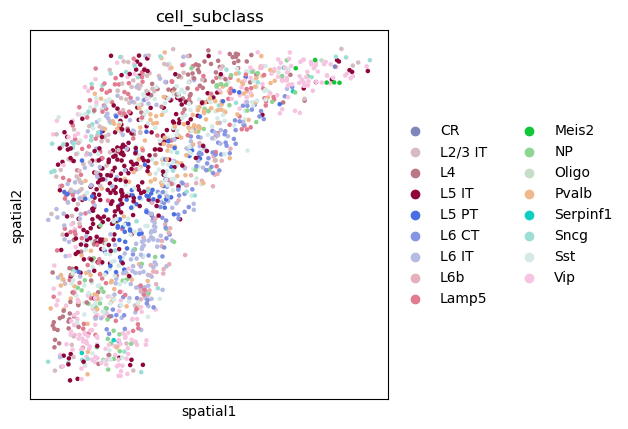

In [ ]:
sc.pl.spatial(adata_st, color = 'cluster')
sc.pl.spatial(adata_cr, color = 'cell_subclass',spot_size = 100)

In [30]:
sem = cr.tl.cell_shape_modeling(adata_cr,cluster_key = 'cell_subclass')

Simulation:   0%|          | 0/2000 [00:00<?, ?it/s]/home/kxy/miniconda3/envs/dl/lib/python3.9/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 85 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
Simulation: 100%|██████████| 2000/2000 [00:27<00:00, 72.99it/s]


add .obsp['contacts'], .uns['contacts']
Computing alpha-shape with parameters: alpha=None, ns=10, r=1.2


Processing Cell Shapes: 100%|██████████| 1620/1620 [00:15<00:00, 104.02it/s]


<Axes: >

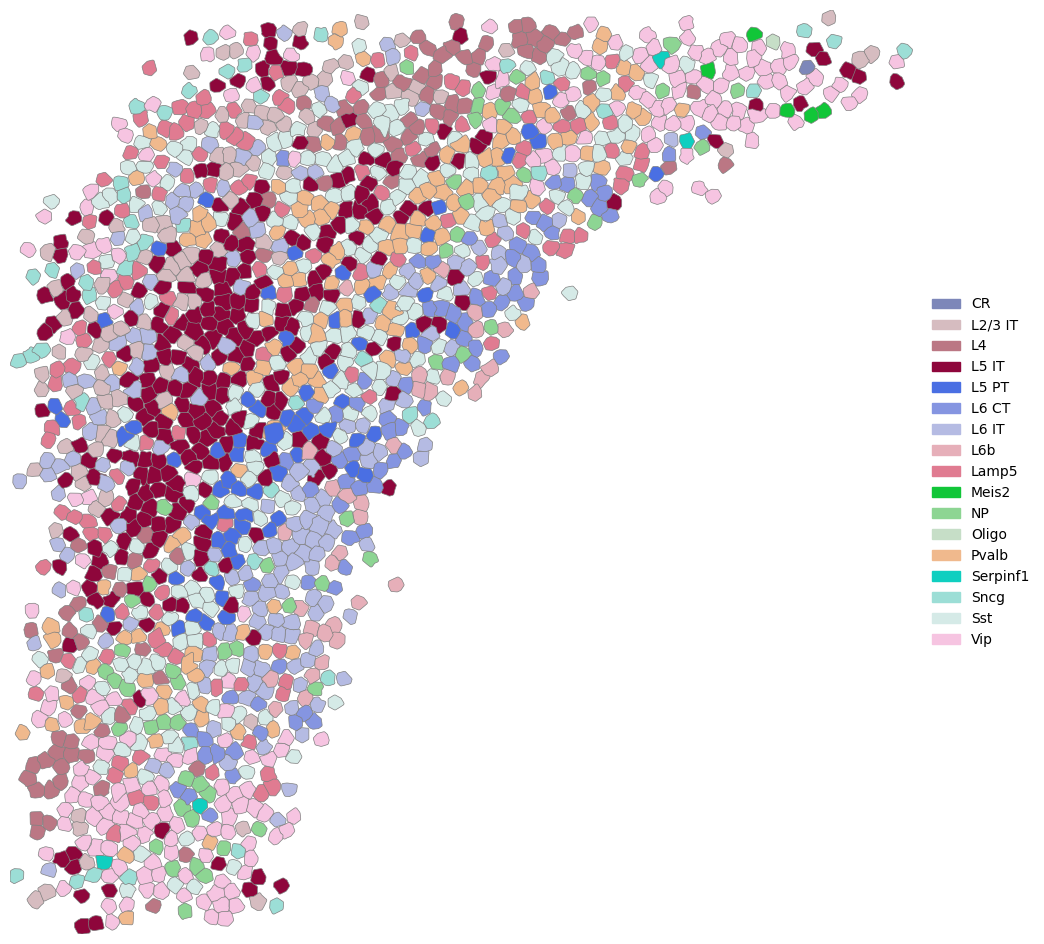

In [31]:
fig,ax=plt.subplots(figsize=(12,12))
cr.pl.plot_cell_shape(sem,ax=ax,boundary_color='gray',boundary_width=0.5)

In [28]:
db_lr = cr.pp.ligand_receptor_database()
db_lr = cr.pp.filter_lr_database(db_lr,adata_cr, min_cell_pct=0.01)
cr.tl.contact_communication(db_lr,sem)

<Axes: >

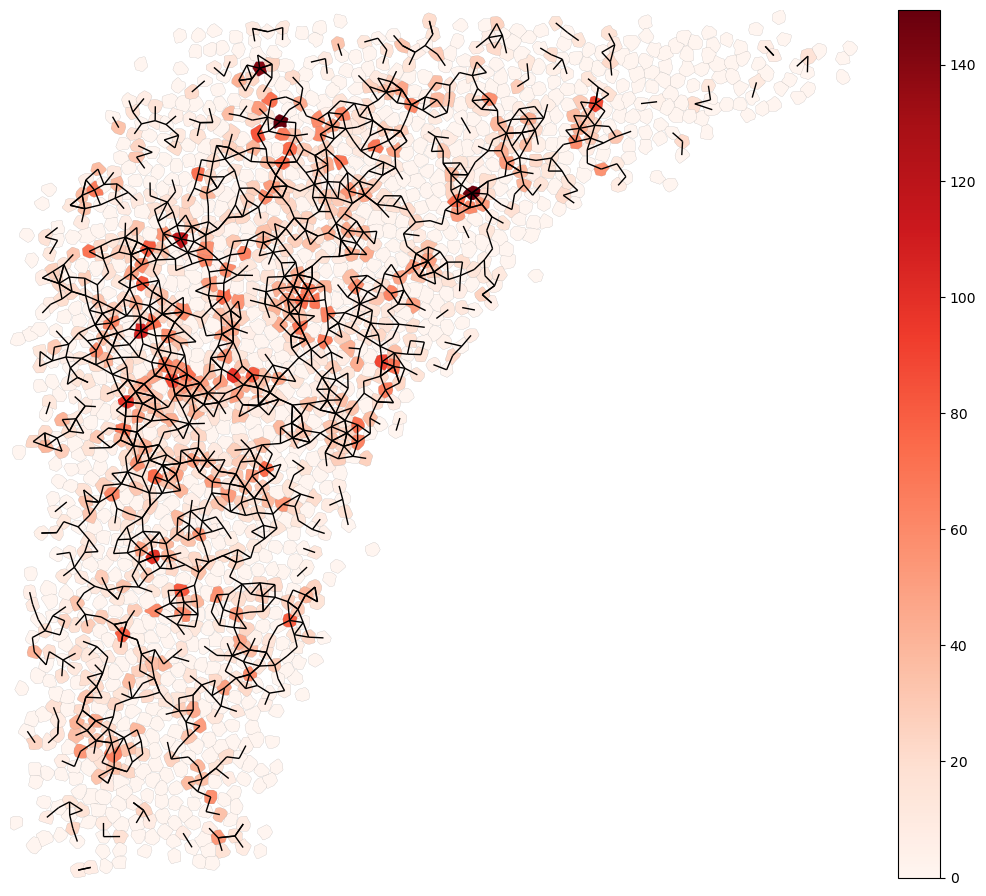

In [36]:
fig,ax=plt.subplots(figsize=(12,12))
cr.pl.plot_cell_shape(sem,ax=ax,vis_key='NOTCH',boundary_color='gray',boundary_width=0.1)
cr.pl.plot_contact_signal(sem,ax=ax,signal = 'NOTCH')